# Step 1 — Data Exploration
Walks through every sub-task in `src/features/exploration.py` — no codebase changes, notebook only.

In [1]:
import sys
import logging
from pathlib import Path

# Point Python at src/ so imports match the pipeline
ROOT = Path("../").resolve()
SRC  = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Stream logs to notebook stdout
logging.basicConfig(
    level=logging.INFO,
    format="%(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.config import load_config
from features.exploration import (
    load_data,
    inspect_structure,
    audit_quality,
    profile_columns,
    summarise_observations,
)

cfg = load_config(ROOT / "configs" / "config.toml")
RAW_PATH = ROOT / cfg["data"]["raw_path"]

sns.set_theme(style="whitegrid")
print("Setup complete. ROOT:", ROOT)

Setup complete. ROOT: /home/mbarndouka/Documents/amalitechmllab


---
## 1. Load Data
`load_data()` reads the raw CSV and returns a DataFrame.

In [2]:
df = load_data(RAW_PATH)
print(f"Loaded {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded 57,000 rows × 17 columns


In [3]:
# Visual: first 5 rows
df.head()

,Airline,Source,Source Name,Destination,Destination Name,Departure Date & Time,Arrival Date & Time,Duration (hrs),Stopovers,Aircraft Type,Class,Booking Source,Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Seasonality,Days Before Departure
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17 06:25:00,2025-11-17 07:38:10,1.219526,Direct,Airbus A320,Economy,Online Website,21131.225021,5169.683753,26300.908775,Regular,10
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16 00:17:00,2025-03-16 00:53:31,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.395471,200.000000,11805.395471,Regular,14
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13 12:03:00,2025-12-13 14:44:22,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.499349,11982.374902,51864.874251,Winter Holidays,83
3,Singapore Airlines,RJH,"Shah Makhdum Airport, Rajshahi",DAC,"Hazrat Shahjalal International Airport, Dhaka",2025-05-30 03:21:00,2025-05-30 04:02:09,0.686054,Direct,Airbus A320,Economy,Direct Booking,4435.607340,200.000000,4635.607340,Regular,56
4,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,2025-04-25 09:14:00,2025-04-25 23:17:20,14.055609,1 Stop,Airbus A350,Business,Direct Booking,59243.806146,14886.570922,74130.377068,Regular,90


---
## 2. Inspect Structure
`inspect_structure()` logs head, shape, dtypes, and numerical summary.

In [4]:
inspect_structure(df)

2026-05-14 10:39:30 [INFO] features.exploration: === HEAD (5 rows) ===


=== HEAD (5 rows) ===


2026-05-14 10:39:30 [INFO] features.exploration: 
              Airline Source                           Source Name Destination                                           Destination Name Departure Date & Time  Arrival Date & Time  Duration (hrs) Stopovers Aircraft Type        Class  Booking Source  Base Fare (BDT)  Tax & Surcharge (BDT)  Total Fare (BDT)      Seasonality  Days Before Departure
0  Malaysian Airlines    CXB                   Cox's Bazar Airport         CCU  Netaji Subhas Chandra Bose International Airport, Kolkata   2025-11-17 06:25:00  2025-11-17 07:38:10        1.219526    Direct   Airbus A320      Economy  Online Website     21131.225021            5169.683753      26300.908775          Regular                     10
1      Cathay Pacific    BZL                       Barisal Airport         CGP              Shah Amanat International Airport, Chittagong   2025-03-16 00:17:00  2025-03-16 00:53:31        0.608638    Direct   Airbus A320  First Class   Travel Agency     


              Airline Source                           Source Name Destination                                           Destination Name Departure Date & Time  Arrival Date & Time  Duration (hrs) Stopovers Aircraft Type        Class  Booking Source  Base Fare (BDT)  Tax & Surcharge (BDT)  Total Fare (BDT)      Seasonality  Days Before Departure
0  Malaysian Airlines    CXB                   Cox's Bazar Airport         CCU  Netaji Subhas Chandra Bose International Airport, Kolkata   2025-11-17 06:25:00  2025-11-17 07:38:10        1.219526    Direct   Airbus A320      Economy  Online Website     21131.225021            5169.683753      26300.908775          Regular                     10
1      Cathay Pacific    BZL                       Barisal Airport         CGP              Shah Amanat International Airport, Chittagong   2025-03-16 00:17:00  2025-03-16 00:53:31        0.608638    Direct   Airbus A320  First Class   Travel Agency     11605.395471             200.000000      11805.39

2026-05-14 10:39:30 [INFO] features.exploration: === SHAPE ===


...


  Airline                                       dtype=object       non-null=57000
  Source                                        dtype=object       non-null=57000
  Source Name                                   dtype=object       non-null=57000
  Destination                                   dtype=object       non-null=57000
  Destination Name                              dtype=object       non-null=57000
  Departure Date & Time                         dtype=object       non-null=57000
  Arrival Date & Time                           dtype=object       non-null=57000
  Duration (hrs)                                dtype=float64      non-null=57000
  Stopovers                                     dtype=object       non-null=57000
  Aircraft Type                                 dtype=object       non-null=57000
  Class                                         dtype=object       non-null=57000
  Booking Source                                dtype=object       non-null=57000
  Base Fare (BD

2026-05-14 10:39:30 [INFO] features.exploration: === NUMERICAL SUMMARY (.describe()) ===


=== NUMERICAL SUMMARY (.describe()) ===


2026-05-14 10:39:30 [INFO] features.exploration: 
       Duration (hrs)  Base Fare (BDT)  Tax & Surcharge (BDT)  Total Fare (BDT)  Days Before Departure
count        57000.00         57000.00               57000.00          57000.00               57000.00
mean             3.99         58899.56               11448.24          71030.32                  45.46
std              4.09         68840.61               12124.34          81769.20                  26.02
min              0.50          1600.98                 200.00           1800.98                   1.00
25%              1.00          8856.32                 200.00           9602.70                  23.00
50%              2.64         31616.00                9450.94          41307.54                  45.00
75%              5.49         85722.93               17513.05         103800.91                  68.00
max             15.83        449222.93               73383.44         558987.33                  90.00



       Duration (hrs)  Base Fare (BDT)  Tax & Surcharge (BDT)  Total Fare (BDT)  Days Before Departure
count        57000.00         57000.00               57000.00          57000.00               57000.00
mean             3.99         58899.56               11448.24          71030.32                  45.46
std              4.09         68840.61               12124.34          81769.20                  26.02
min              0.50          1600.98                 200.00           1800.98                   1.00
25%              1.00          8856.32                 200.00           9602.70                  23.00
50%              2.64         31616.00                9450.94          41307.54                  45.00
75%              5.49         85722.93               17513.05         103800.91                  68.00
max             15.83        449222.93               73383.44         558987.33                  90.00


In [5]:
# Visual: dtype overview
pd.DataFrame({
    "dtype":    df.dtypes,
    "non_null": df.notna().sum(),
    "null":     df.isna().sum(),
})

,dtype,non_null,null
Airline,object,57000,0
Source,object,57000,0
Source Name,object,57000,0
Destination,object,57000,0
Destination Name,object,57000,0
Departure Date & Time,object,57000,0
Arrival Date & Time,object,57000,0
Duration (hrs),float64,57000,0
Stopovers,object,57000,0
Aircraft Type,object,57000,0


In [6]:
# Visual: numerical summary
df.describe(include="number").round(2)

,Duration (hrs),Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Days Before Departure
count,57000.00,57000.00,57000.00,57000.00,57000.00
mean,3.99,58899.56,11448.24,71030.32,45.46
std,4.09,68840.61,12124.34,81769.20,26.02
min,0.50,1600.98,200.00,1800.98,1.00
25%,1.00,8856.32,200.00,9602.70,23.00
50%,2.64,31616.00,9450.94,41307.54,45.00
75%,5.49,85722.93,17513.05,103800.91,68.00
max,15.83,449222.93,73383.44,558987.33,90.00


---
## 3. Audit Quality
`audit_quality()` checks missing values and duplicate rows.

In [7]:
audit_quality(df)

2026-05-14 10:39:31 [INFO] features.exploration: === MISSING VALUES ===


=== MISSING VALUES ===


2026-05-14 10:39:31 [INFO] features.exploration:   No missing values found.


  No missing values found.


2026-05-14 10:39:31 [INFO] features.exploration: === DUPLICATE ROWS ===


=== DUPLICATE ROWS ===


2026-05-14 10:39:31 [INFO] features.exploration:   Duplicate rows: 0  (0.00%)


  Duplicate rows: 0  (0.00%)


In [8]:
# Visual: missing values bar chart (only columns with nulls)
missing = df.isna().sum()
missing = missing[missing > 0]

if missing.empty:
    print("No missing values — nothing to plot.")
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    missing.sort_values().plot(kind="barh", ax=ax)
    ax.set_title("Missing values per column")
    ax.set_xlabel("Count")
    plt.tight_layout()
    plt.show()

No missing values — nothing to plot.


In [9]:
# Visual: duplicate check
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}  ({dupes/len(df)*100:.2f}%)")

Duplicate rows: 0  (0.00%)


---
## 4. Profile Columns
`profile_columns()` classifies every column as numerical / categorical / datetime,
then logs cardinality, min/max/skew, and IQR outlier counts.

In [10]:
classification = profile_columns(df)

2026-05-14 10:39:31 [INFO] features.exploration: === COLUMN CLASSIFICATION ===


=== COLUMN CLASSIFICATION ===


2026-05-14 10:39:31 [INFO] features.exploration:   numerical:      ['Duration (hrs)', 'Base Fare (BDT)', 'Tax & Surcharge (BDT)', 'Total Fare (BDT)', 'Days Before Departure']


  numerical:      ['Duration (hrs)', 'Base Fare (BDT)', 'Tax & Surcharge (BDT)', 'Total Fare (BDT)', 'Days Before Departure']


2026-05-14 10:39:31 [INFO] features.exploration:   categorical:    ['Airline', 'Source', 'Source Name', 'Destination', 'Destination Name', 'Stopovers', 'Aircraft Type', 'Class', 'Booking Source', 'Seasonality']


...

  Tax & Surcharge (BDT)                       min=200.00        max=73383.44      skew=1.13      outliers=1226 (2.2%)


2026-05-14 10:39:31 [INFO] features.exploration:   Total Fare (BDT)                            min=1800.98       max=558987.33     skew=1.58      outliers=3409 (6.0%)


  Total Fare (BDT)                            min=1800.98       max=558987.33     skew=1.58      outliers=3409 (6.0%)


2026-05-14 10:39:31 [INFO] features.exploration:   Days Before Departure                       min=1.00          max=90.00         skew=0.00      outliers=0 (0.0%)


  Days Before Departure                       min=1.00          max=90.00         skew=0.00      outliers=0 (0.0%)


In [11]:
# Visual: column classification summary
pd.DataFrame(
    [(kind, col) for kind, cols in classification.items() for col in cols],
    columns=["kind", "column"],
).set_index("column")

,kind
column,
Duration (hrs),numerical
Base Fare (BDT),numerical
Tax & Surcharge (BDT),numerical
Total Fare (BDT),numerical
Days Before Departure,numerical
Airline,categorical
Source,categorical
Source Name,categorical
Destination,categorical


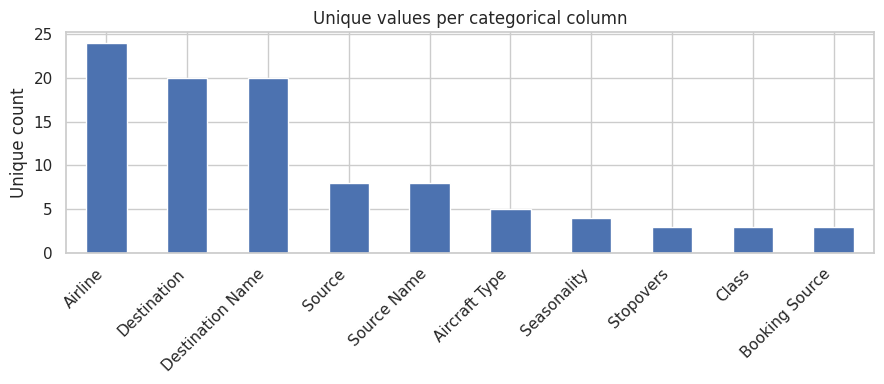

In [12]:
# Visual: cardinality of categorical columns
cat_cols = classification["categorical"]
if cat_cols:
    cardinality = df[cat_cols].nunique().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(9, 4))
    cardinality.plot(kind="bar", ax=ax)
    ax.set_title("Unique values per categorical column")
    ax.set_ylabel("Unique count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

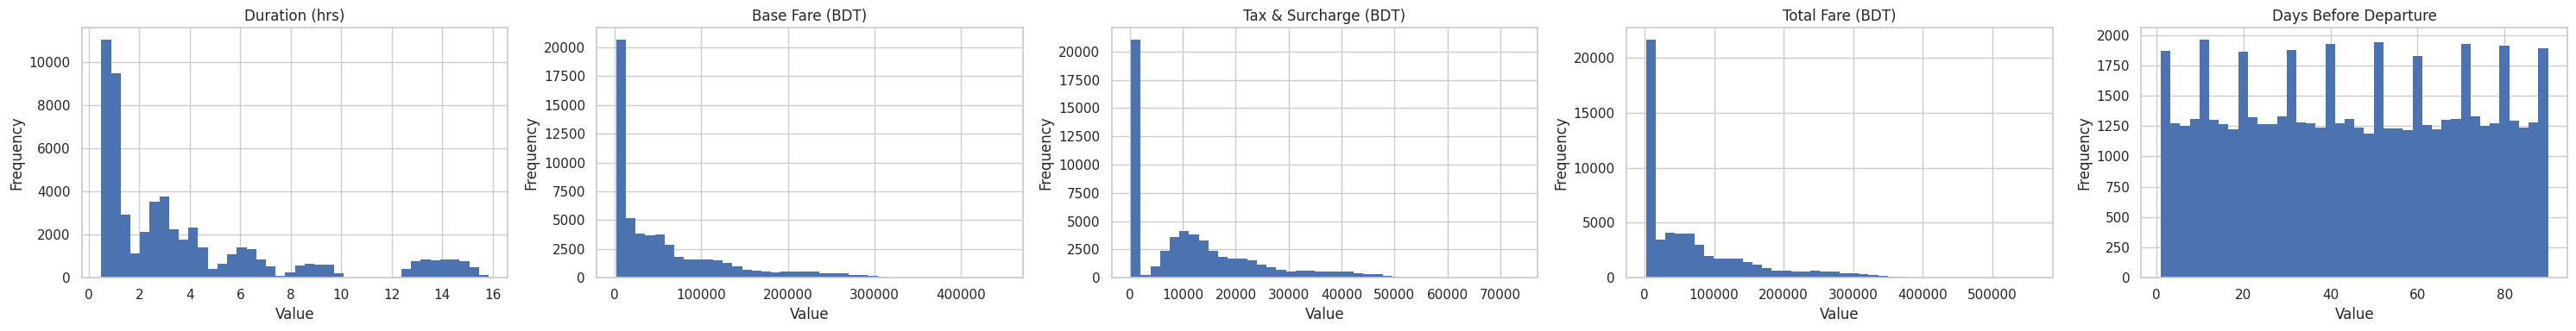

In [13]:
# Visual: distributions of numerical columns
num_cols = classification["numerical"]
if num_cols:
    n = len(num_cols)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    axes = [axes] if n == 1 else axes
    for ax, col in zip(axes, num_cols):
        df[col].dropna().hist(bins=40, ax=ax, edgecolor="none")
        ax.set_title(col)
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()

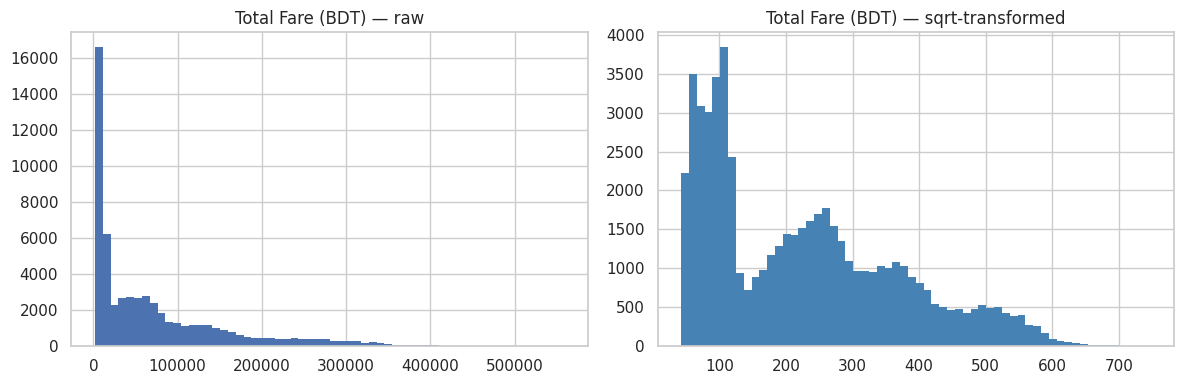

In [14]:
# Visual: target distribution (Total Fare)
target = "Total Fare (BDT)"
if target in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    df[target].hist(bins=60, ax=axes[0], edgecolor="none")
    axes[0].set_title(f"{target} — raw")
    df[target].apply(lambda x: x**0.5).hist(bins=60, ax=axes[1], edgecolor="none", color="steelblue")
    axes[1].set_title(f"{target} — sqrt-transformed")
    plt.tight_layout()
    plt.show()

In [15]:
# Visual: IQR outlier counts per numerical column
rows = []
for col in num_cols:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    n_out = int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())
    rows.append({"column": col, "outliers": n_out, "outliers_%": round(n_out / len(s) * 100, 2)})
pd.DataFrame(rows).set_index("column")

,outliers,outliers_%
column,,
Duration (hrs),5984,10.50
Base Fare (BDT),3772,6.62
Tax & Surcharge (BDT),1226,2.15
Total Fare (BDT),3409,5.98
Days Before Departure,0,0.00


In [16]:
# Visual: datetime columns — raw values & what parse gives us
dt_cols = classification["datetime"]
print("Datetime-like columns detected:", dt_cols)
print()
for col in dt_cols:
    print(f"--- {col} ---")
    parsed = pd.to_datetime(df[col], errors="coerce")
    print("Raw sample  :", df[col].iloc[0])
    print("Parsed dtype:", parsed.dtype)
    print("Parsed value:", parsed.iloc[0])
    print("  → hour         :", parsed.dt.hour.iloc[0])
    print("  → day_of_week  :", parsed.dt.day_name().iloc[0])
    print("  → month        :", parsed.dt.month_name().iloc[0])
    print()

Datetime-like columns detected: ['Departure Date & Time', 'Arrival Date & Time']

--- Departure Date & Time ---
Raw sample  : 2025-11-17 06:25:00
Parsed dtype: datetime64[ns]
Parsed value: 2025-11-17 06:25:00
  → hour         : 6
  → day_of_week  : Monday
  → month        : November

--- Arrival Date & Time ---
Raw sample  : 2025-11-17 07:38:10
Parsed dtype: datetime64[ns]
Parsed value: 2025-11-17 07:38:10
  → hour         : 7
  → day_of_week  : Monday
  → month        : November



---
## Summary

| Dimension | Finding |
|---|---|
| Dataset size | 57,000 rows × 17 columns |
| Target variable | Total Fare (BDT) — range BDT 1,801 to BDT 558,987 |
| Target distribution | Right-skewed (mean BDT 71,030 vs median BDT 41,308) — log transform needed |
| Missing values | None |
| Duplicate rows | None |
| Numerical features | Duration, Days Before Departure (+ leakage cols Base Fare, Tax & Surcharge) |
| Categorical features | Airline, Source, Destination, Stopovers, Aircraft Type, Class, Booking Source, Seasonality |
| Datetime features | Departure and Arrival timestamps → extracted to hour, day-of-week, month |
| Data leakage | `Base Fare` and `Tax & Surcharge` are sub-components of the target — must be dropped |

**Next step:** clean the data — rename columns, drop leakage columns, parse datetimes, extract temporal features.

In [17]:
summarise_observations(df, classification)

2026-05-14 10:39:33 [INFO] features.exploration: === INITIAL OBSERVATIONS ===


=== INITIAL OBSERVATIONS ===


2026-05-14 10:39:33 [INFO] features.exploration:   Rows x Columns      : 57000 x 17


  Rows x Columns      : 57000 x 17


2026-05-14 10:39:33 [INFO] features.exploration:   Target variable     : Total Fare (BDT)


...

  • 'Stopovers' is ordinal: Direct < 1 Stop < 2+ Stops.


2026-05-14 10:39:33 [INFO] features.exploration:   • Dataset covers Bangladesh-origin routes only.


  • Dataset covers Bangladesh-origin routes only.


2026-05-14 10:39:33 [INFO] features.exploration:   • All monetary values are in BDT (Bangladeshi Taka).


  • All monetary values are in BDT (Bangladeshi Taka).


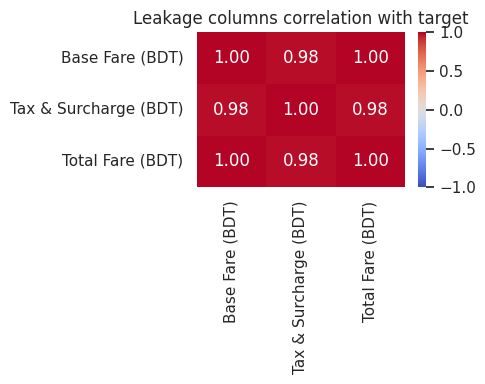

In [18]:
# Visual: leakage columns vs target correlation
leakage_cols = ["Base Fare (BDT)", "Tax & Surcharge (BDT)"]
available = [c for c in leakage_cols if c in df.columns]
if available and target in df.columns:
    corr_data = df[available + [target]].corr()
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(corr_data, annot=True, fmt=".2f", ax=ax, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title("Leakage columns correlation with target")
    plt.tight_layout()
    plt.show()

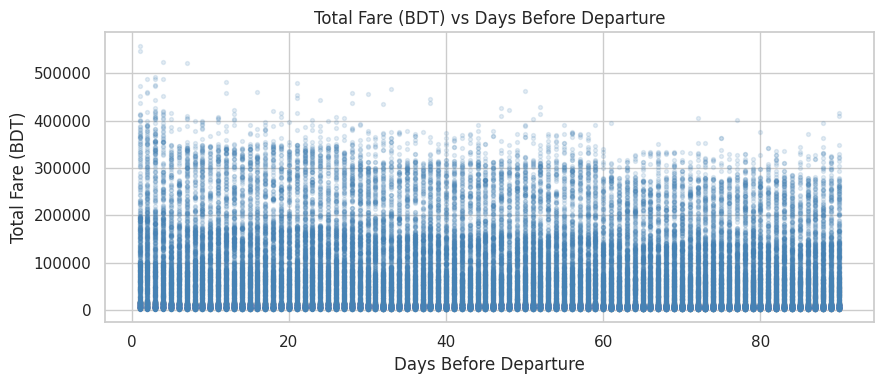

In [19]:
# Visual: target vs Days Before Departure
days_col = "Days Before Departure"
if days_col in df.columns and target in df.columns:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.scatter(df[days_col], df[target], alpha=0.15, s=8, color="steelblue")
    ax.set_xlabel(days_col)
    ax.set_ylabel(target)
    ax.set_title(f"{target} vs {days_col}")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_64749/2521698226.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
/tmp/ipykernel_64749/2521698226.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


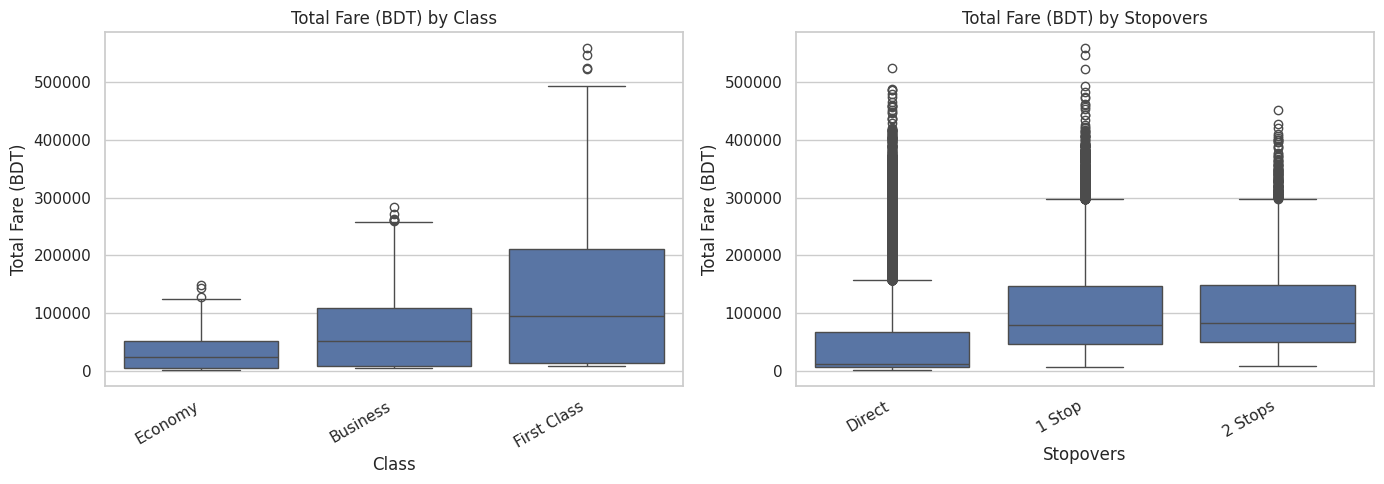

In [20]:
# Visual: target by Class and Stopovers
class_col    = "Class"
stopover_col = "Stopovers"
available_cats = [c for c in [class_col, stopover_col] if c in df.columns]

if available_cats and target in df.columns:
    fig, axes = plt.subplots(1, len(available_cats), figsize=(7 * len(available_cats), 5))
    axes = [axes] if len(available_cats) == 1 else axes
    for ax, col in zip(axes, available_cats):
        order = df.groupby(col)[target].median().sort_values().index
        sns.boxplot(data=df, x=col, y=target, order=order, ax=ax)
        ax.set_title(f"{target} by {col}")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    plt.tight_layout()
    plt.show()